# 02. Feature Engineering cho Hybrid Recommender

**Mục tiêu:**
1. Tạo user-item matrix cho CF (ALS)
2. Tạo co-occurrence matrix cho basket recommendation ("mua kèm")
3. Tạo popularity baseline (fallback cold-start)
4. Lưu artifacts dạng pickle/npz để inference nhanh

In [1]:
from pathlib import Path
import json

import pandas as pd
import numpy as np
from scipy.sparse import csr_matrix, save_npz
from collections import defaultdict

# Setup paths
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PROCESSED_DIR = PROJECT_ROOT / "data" / "02_processed"
FEATURES_DIR = PROJECT_ROOT / "data" / "03_features"
VIZ_DIR = PROJECT_ROOT / "visualizations" / "02_feature_engineering"

FEATURES_DIR.mkdir(parents=True, exist_ok=True)
VIZ_DIR.mkdir(parents=True, exist_ok=True)

if not PROCESSED_DIR.exists():
    raise FileNotFoundError(
        f"Không tìm thấy PROCESSED_DIR: {PROCESSED_DIR}\n"
        "Hãy chạy notebook 01_data_preparation trước, hoặc kiểm tra lại PROJECT_ROOT/cwd."
    )

print(f"PROJECT_ROOT: {PROJECT_ROOT}")
print(f"PROCESSED_DIR: {PROCESSED_DIR}")
print(f"FEATURES_DIR: {FEATURES_DIR}")
print(f"VIZ_DIR: {VIZ_DIR}")

PROJECT_ROOT: e:\Nam3\TailLieuHocKi7\WEB2\VuaVuiVeNC\VuaVuiVe_Recommender
PROCESSED_DIR: e:\Nam3\TailLieuHocKi7\WEB2\VuaVuiVeNC\VuaVuiVe_Recommender\data\02_processed
FEATURES_DIR: e:\Nam3\TailLieuHocKi7\WEB2\VuaVuiVeNC\VuaVuiVe_Recommender\data\03_features
VIZ_DIR: e:\Nam3\TailLieuHocKi7\WEB2\VuaVuiVeNC\VuaVuiVe_Recommender\visualizations\02_feature_engineering


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

## Load Processed Data

In [3]:
orders = pd.read_parquet(PROCESSED_DIR / "orders.parquet")
products = pd.read_parquet(PROCESSED_DIR / "products.parquet")
op_prior = pd.read_parquet(PROCESSED_DIR / "order_products__prior.parquet")

print(f"orders: {orders.shape}")
print(f"products: {products.shape}")
print(f"op_prior: {op_prior.shape}")

orders: (3421083, 7)
products: (49688, 6)
op_prior: (32434489, 4)


In [4]:
# Filter orders: chỉ lấy eval_set='prior' để train
orders_prior = orders[orders["eval_set"] == "prior"].copy()
print(f"orders_prior: {orders_prior.shape}")

orders_prior: (3214874, 7)


## Feature 1: User-Item Matrix cho CF (ALS)

In [5]:
# Join op_prior + orders_prior để có user_id
df_cf = op_prior.merge(
    orders_prior[["order_id", "user_id"]], 
    on="order_id", 
    how="inner"
)
print(f"df_cf shape: {df_cf.shape}")

# Tính interaction count: số lần user mua product
interactions = df_cf.groupby(["user_id", "product_id"]).size().reset_index(name="count")
print(f"Unique (user, product) pairs: {len(interactions)}")
interactions.head()

df_cf shape: (32434489, 5)
Unique (user, product) pairs: 13307953


,user_id,product_id,count
0,1,196,10
1,1,10258,9
2,1,10326,1
3,1,12427,10
4,1,13032,3


In [6]:
# Tạo mappings (ID → index liên tục từ 0)
user_ids = interactions["user_id"].unique()
prod_ids = interactions["product_id"].unique()

user2idx = {int(uid): i for i, uid in enumerate(user_ids)}
prod2idx = {int(pid): i for i, pid in enumerate(prod_ids)}
idx2user = {i: int(uid) for uid, i in user2idx.items()}
idx2prod = {i: int(pid) for pid, i in prod2idx.items()}

print(f"Users: {len(user2idx)}, Products: {len(prod2idx)}")

Users: 206209, Products: 49677


In [7]:
# Build user-item sparse matrix
row = interactions["user_id"].map(user2idx).to_numpy()
col = interactions["product_id"].map(prod2idx).to_numpy()
data = interactions["count"].astype("float32").to_numpy()

user_item_matrix = csr_matrix(  # type: ignore
    (data, (row, col)), 
    shape=(len(user2idx), len(prod2idx)),
    dtype=np.float32
)
print(f"user_item_matrix shape: {user_item_matrix.shape}")

# Calculate sparsity
n_users, n_products = user_item_matrix.shape  # type: ignore
total_cells = n_users * n_products
filled_cells = user_item_matrix.nnz  # type: ignore
sparsity_pct = 100 * (1 - filled_cells / total_cells)
print(f"Sparsity: {sparsity_pct:.2f}%")

user_item_matrix shape: (206209, 49677)
Sparsity: 99.87%


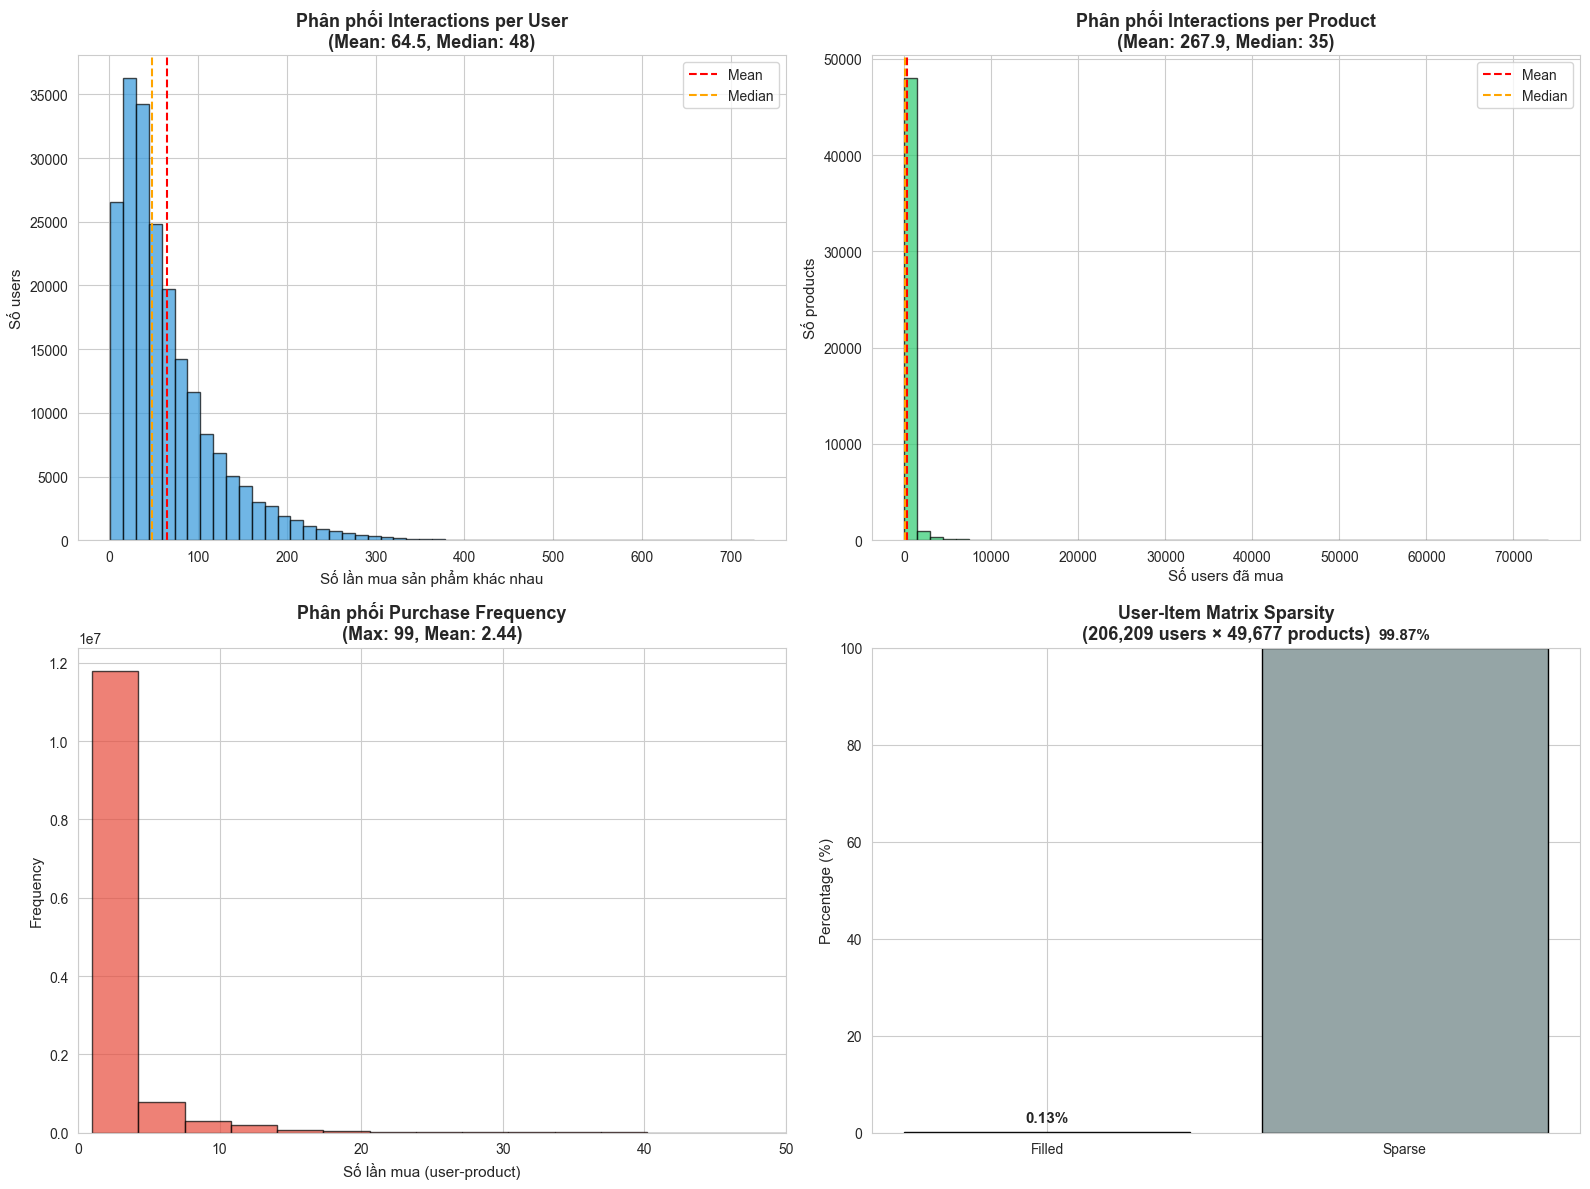

✓ Saved: e:\Nam3\TailLieuHocKi7\WEB2\VuaVuiVeNC\VuaVuiVe_Recommender\visualizations\02_feature_engineering\01_user_product_interactions.png


In [8]:
# Visualization: User-Product Interactions
fig, ax = plt.subplots(2, 2, figsize=(16, 12))

# 1) Distribution of interactions per user
user_interaction_counts = interactions.groupby("user_id").size()
ax[0, 0].hist(user_interaction_counts, bins=50, color='#3498db', edgecolor='black', alpha=0.7)
ax[0, 0].set_xlabel('Số lần mua sản phẩm khác nhau', fontsize=11)
ax[0, 0].set_ylabel('Số users', fontsize=11)
ax[0, 0].set_title(f'Phân phối Interactions per User\n(Mean: {user_interaction_counts.mean():.1f}, Median: {user_interaction_counts.median():.0f})', 
                   fontsize=13, fontweight='bold')
ax[0, 0].axvline(user_interaction_counts.mean(), color='red', linestyle='--', label='Mean')
ax[0, 0].axvline(user_interaction_counts.median(), color='orange', linestyle='--', label='Median')
ax[0, 0].legend()

# 2) Distribution of interactions per product
product_interaction_counts = interactions.groupby("product_id").size()
ax[0, 1].hist(product_interaction_counts, bins=50, color='#2ecc71', edgecolor='black', alpha=0.7)
ax[0, 1].set_xlabel('Số users đã mua', fontsize=11)
ax[0, 1].set_ylabel('Số products', fontsize=11)
ax[0, 1].set_title(f'Phân phối Interactions per Product\n(Mean: {product_interaction_counts.mean():.1f}, Median: {product_interaction_counts.median():.0f})', 
                   fontsize=13, fontweight='bold')
ax[0, 1].axvline(product_interaction_counts.mean(), color='red', linestyle='--', label='Mean')
ax[0, 1].axvline(product_interaction_counts.median(), color='orange', linestyle='--', label='Median')
ax[0, 1].legend()

# 3) Purchase frequency distribution
purchase_freq = interactions["count"]
ax[1, 0].hist(purchase_freq, bins=30, color='#e74c3c', edgecolor='black', alpha=0.7)
ax[1, 0].set_xlabel('Số lần mua (user-product)', fontsize=11)
ax[1, 0].set_ylabel('Frequency', fontsize=11)
ax[1, 0].set_title(f'Phân phối Purchase Frequency\n(Max: {purchase_freq.max()}, Mean: {purchase_freq.mean():.2f})', 
                   fontsize=13, fontweight='bold')
ax[1, 0].set_xlim(0, min(purchase_freq.max(), 50))

# 4) Matrix sparsity visualization (user_item_matrix defined in previous cell)
n_users = user_item_matrix.shape[0]  # type: ignore
n_products = user_item_matrix.shape[1]  # type: ignore
total_cells = n_users * n_products
filled_cells = user_item_matrix.nnz  # type: ignore
sparsity = 100 * (1 - filled_cells / total_cells)

ax[1, 1].bar(['Filled', 'Sparse'], 
             [100 - sparsity, sparsity], 
             color=['#2ecc71', '#95a5a6'], edgecolor='black')
ax[1, 1].set_ylabel('Percentage (%)', fontsize=11)
ax[1, 1].set_title(f'User-Item Matrix Sparsity\n({n_users:,} users × {n_products:,} products)', 
                   fontsize=13, fontweight='bold')
ax[1, 1].set_ylim(0, 100)
for i, v in enumerate([100 - sparsity, sparsity]):
    ax[1, 1].text(i, v + 2, f'{v:.2f}%', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig(VIZ_DIR / "01_user_product_interactions.png", dpi=100, bbox_inches='tight')
plt.show()
print(f"✓ Saved: {VIZ_DIR / '01_user_product_interactions.png'}")

In [9]:
# Save CF artifacts
save_npz(FEATURES_DIR / "user_item_matrix.npz", user_item_matrix)

with open(FEATURES_DIR / "cf_mappings.json", "w", encoding="utf-8") as f:
    json.dump({
        "user2idx": user2idx,
        "prod2idx": prod2idx,
        "idx2user": idx2user,
        "idx2prod": idx2prod,
    }, f, ensure_ascii=False, indent=2)

print(f"✓ Saved CF artifacts to {FEATURES_DIR}")

✓ Saved CF artifacts to e:\Nam3\TailLieuHocKi7\WEB2\VuaVuiVeNC\VuaVuiVe_Recommender\data\03_features


## Feature 2: Co-occurrence Matrix (Basket/"Mua kèm")

In [10]:
# Tạo dict: order_id -> set(product_ids)
baskets = op_prior.groupby("order_id")["product_id"].apply(set).to_dict()
print(f"Số đơn hàng (baskets): {len(baskets)}")

if len(baskets) > 0:
    sample_basket = next(iter(baskets.values()))
    print(f"Sample basket: {sample_basket}")
else:
    print("⚠️ baskets rỗng: kiểm tra op_prior / dữ liệu đầu vào")

Số đơn hàng (baskets): 3214874
Sample basket: {33120, 17794, 40141, 9327, 30035, 43668, 28985, 1819, 45918}


In [11]:
# Tính co-occurrence: đếm số lần A và B xuất hiện cùng nhau trong 1 đơn
cooccur = defaultdict(lambda: defaultdict(int))

for basket in baskets.values():
    items = list(basket)
    for i, item_a in enumerate(items):
        for item_b in items[i+1:]:
            cooccur[item_a][item_b] += 1
            cooccur[item_b][item_a] += 1  # symmetric

print(f"Có {len(cooccur)} products có co-occurrence")

Có 49674 products có co-occurrence


In [12]:
# Tạo neighbor table: top-K items liên quan cho mỗi product
TOP_K = 50

neighbors = {}
for prod, related in cooccur.items():
    # Sort theo count giảm dần, lấy top K
    top = sorted(related.items(), key=lambda x: x[1], reverse=True)[:TOP_K]
    neighbors[int(prod)] = [(int(p), int(cnt)) for p, cnt in top]

print(f"Tạo neighbor table cho {len(neighbors)} products")
print(f"Sample neighbors of product {list(neighbors.keys())[0]}: {neighbors[list(neighbors.keys())[0]][:5]}")

Tạo neighbor table cho 49674 products
Sample neighbors of product 33120: [(21903, 4471), (13176, 3597), (24852, 3505), (47209, 2720), (21137, 2696)]


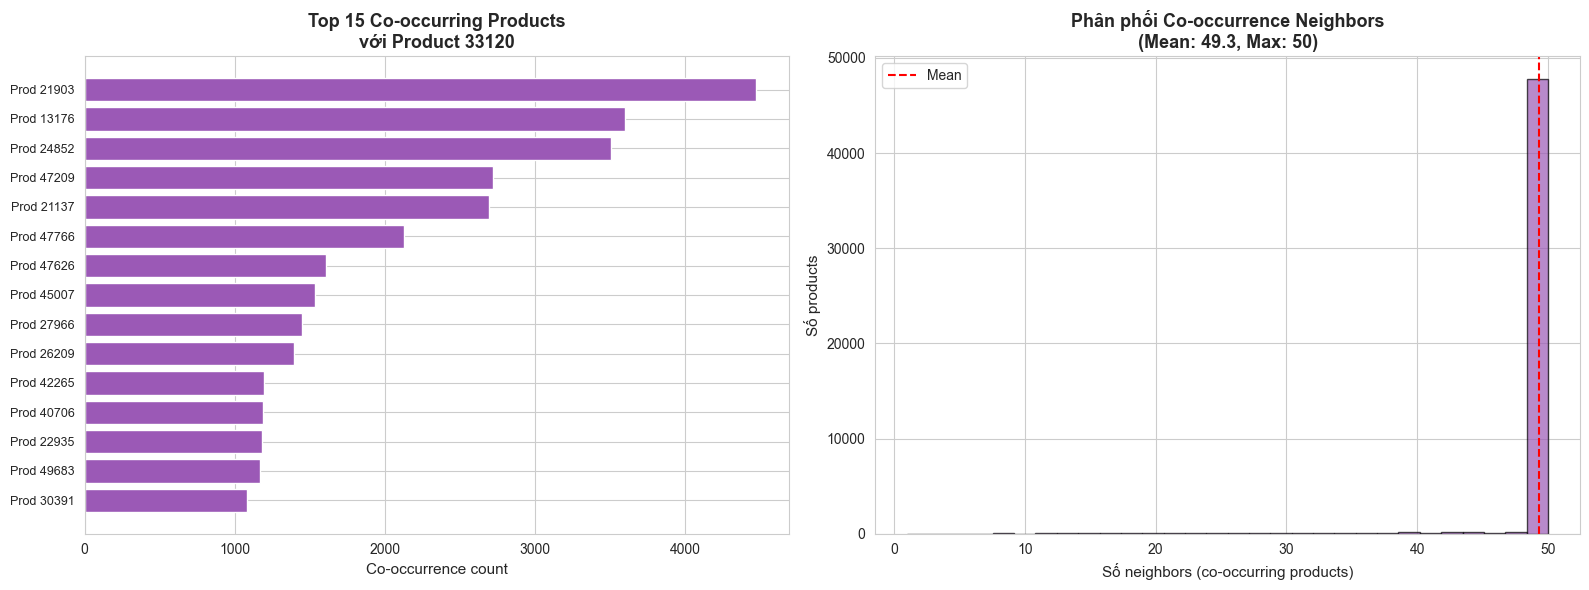

✓ Saved: e:\Nam3\TailLieuHocKi7\WEB2\VuaVuiVeNC\VuaVuiVe_Recommender\visualizations\02_feature_engineering\02_basket_cooccurrence.png


In [13]:
# Visualization: Basket Co-occurrence Network (Sample)
if len(neighbors) == 0:
    print("⚠️ neighbors rỗng: không có co-occurrence để visualize")
else:
    fig, ax = plt.subplots(1, 2, figsize=(16, 6))

    # Chọn sample product có nhiều neighbors nhất để chart dễ nhìn
    sample_prod = max(neighbors.keys(), key=lambda k: len(neighbors[k]))
    sample_neighbors = neighbors[sample_prod][:15]
    neighbor_ids = [p for p, c in sample_neighbors]
    neighbor_counts = [c for p, c in sample_neighbors]

    ax[0].barh(range(len(neighbor_ids)), neighbor_counts[::-1], color='#9b59b6')
    ax[0].set_yticks(range(len(neighbor_ids)))
    ax[0].set_yticklabels([f'Prod {pid}' for pid in neighbor_ids[::-1]], fontsize=9)
    ax[0].set_xlabel('Co-occurrence count', fontsize=11)
    ax[0].set_title(f'Top 15 Co-occurring Products\nvới Product {sample_prod}', fontsize=13, fontweight='bold')

    # Distribution of neighbor counts
    neighbor_sizes = [len(v) for v in neighbors.values()]
    ax[1].hist(neighbor_sizes, bins=30, color='#9b59b6', edgecolor='black', alpha=0.7)
    ax[1].set_xlabel('Số neighbors (co-occurring products)', fontsize=11)
    ax[1].set_ylabel('Số products', fontsize=11)
    ax[1].set_title(
        f'Phân phối Co-occurrence Neighbors\n(Mean: {np.mean(neighbor_sizes):.1f}, Max: {max(neighbor_sizes)})',
        fontsize=13, fontweight='bold',
    )
    ax[1].axvline(np.mean(neighbor_sizes), color='red', linestyle='--', label='Mean')
    ax[1].legend()

    plt.tight_layout()
    plt.savefig(VIZ_DIR / "02_basket_cooccurrence.png", dpi=100, bbox_inches='tight')
    plt.show()
    print(f"✓ Saved: {VIZ_DIR / '02_basket_cooccurrence.png'}")

In [14]:
# Save co-occurrence artifacts
with open(FEATURES_DIR / "cooccurrence_neighbors.json", "w", encoding="utf-8") as f:
    json.dump(neighbors, f, ensure_ascii=False, indent=2)

print(f"✓ Saved co-occurrence neighbors to {FEATURES_DIR}")

✓ Saved co-occurrence neighbors to e:\Nam3\TailLieuHocKi7\WEB2\VuaVuiVeNC\VuaVuiVe_Recommender\data\03_features


## Feature 3: Popularity Baseline (Fallback cho cold-start)

In [15]:
# Đếm số lần mỗi product được mua
product_counts = op_prior["product_id"].value_counts().to_dict()
print(f"Top 10 popular products:")
print(op_prior["product_id"].value_counts().head(10))

Top 10 popular products:
product_id
24852    472565
13176    379450
21137    264683
21903    241921
47209    213584
47766    176815
47626    152657
16797    142951
26209    140627
27845    137905
Name: count, dtype: int64


In [16]:
# Tạo top popular list (global)
top_popular = [(int(pid), int(cnt)) for pid, cnt in 
               sorted(product_counts.items(), key=lambda x: x[1], reverse=True)[:200]]

print(f"Top 5 popular: {top_popular[:5]}")

Top 5 popular: [(24852, 472565), (13176, 379450), (21137, 264683), (21903, 241921), (47209, 213584)]


In [17]:
# Tạo popular by department (để đa dạng hơn)
products_with_dept = products[["product_id", "department_id"]].copy()
op_with_dept = op_prior.merge(products_with_dept, on="product_id", how="left")

popular_by_dept = {}
for dept_id in products["department_id"].unique():
    if pd.isna(dept_id):
        continue
    dept_prods = op_with_dept[op_with_dept["department_id"] == dept_id]["product_id"]
    top_dept = dept_prods.value_counts().head(50).to_dict()
    popular_by_dept[int(dept_id)] = [(int(pid), int(cnt)) for pid, cnt in 
                                      sorted(top_dept.items(), key=lambda x: x[1], reverse=True)]

print(f"Tạo popular cho {len(popular_by_dept)} departments")

Tạo popular cho 21 departments


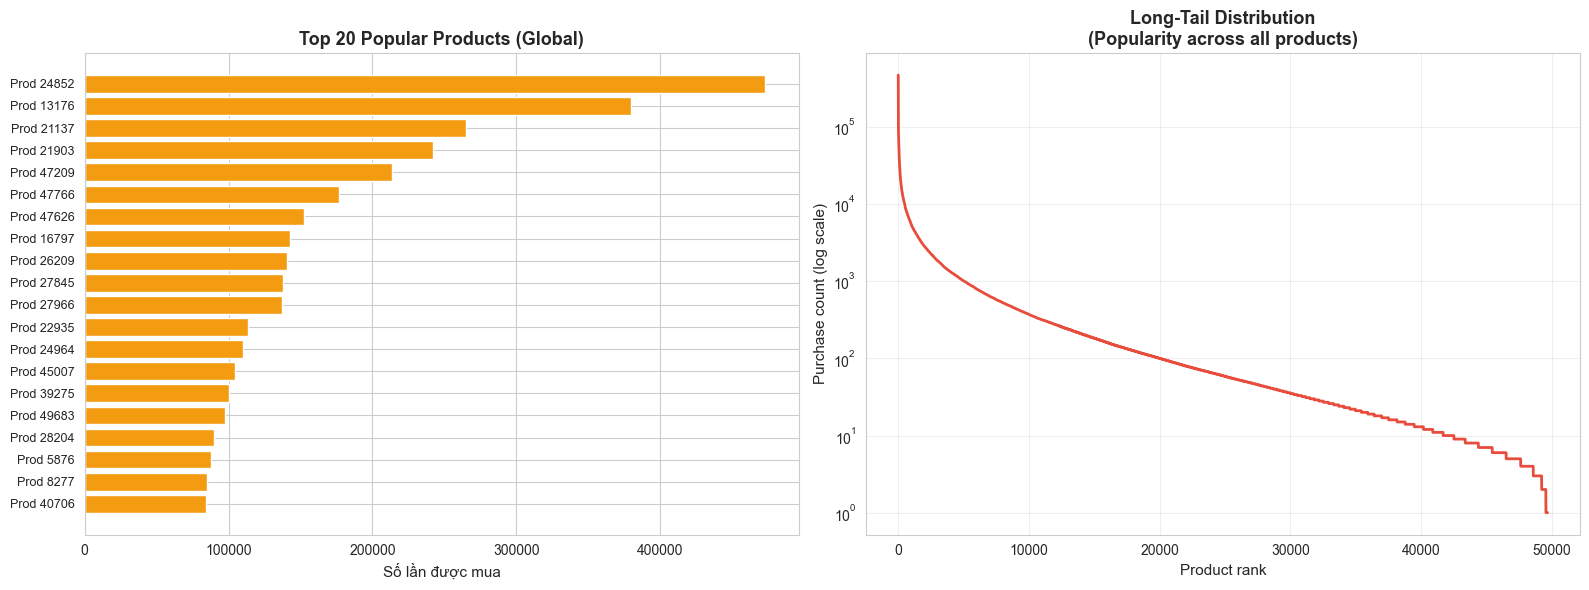

✓ Saved: e:\Nam3\TailLieuHocKi7\WEB2\VuaVuiVeNC\VuaVuiVe_Recommender\visualizations\02_feature_engineering\03_popularity_distribution.png


In [18]:
# Visualization: Popularity Distribution
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# 1) Top 20 popular products (trong top_popular đã cắt top-200)
top20 = top_popular[:20]
prod_ids_top20 = [p for p, c in top20]
counts_top20 = [c for p, c in top20]

ax[0].barh(range(len(prod_ids_top20)), counts_top20[::-1], color='#f39c12')
ax[0].set_yticks(range(len(prod_ids_top20)))
ax[0].set_yticklabels([f'Prod {pid}' for pid in prod_ids_top20[::-1]], fontsize=9)
ax[0].set_xlabel('Số lần được mua', fontsize=11)
ax[0].set_title('Top 20 Popular Products (Global)', fontsize=13, fontweight='bold')

# 2) Long tail distribution (log scale) - dùng TẤT CẢ products
all_counts = sorted(product_counts.values(), reverse=True)
ax[1].plot(range(len(all_counts)), all_counts, color='#e74c3c', linewidth=2)
ax[1].set_xlabel('Product rank', fontsize=11)
ax[1].set_ylabel('Purchase count (log scale)', fontsize=11)
ax[1].set_yscale('log')
ax[1].set_title('Long-Tail Distribution\n(Popularity across all products)', fontsize=13, fontweight='bold')
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(VIZ_DIR / "03_popularity_distribution.png", dpi=100, bbox_inches='tight')
plt.show()
print(f"✓ Saved: {VIZ_DIR / '03_popularity_distribution.png'}")

In [19]:
# Save popularity artifacts
with open(FEATURES_DIR / "popularity.json", "w", encoding="utf-8") as f:
    json.dump({
        "global": top_popular,
        "by_department": popular_by_dept,
    }, f, ensure_ascii=False, indent=2)

print(f"✓ Saved popularity to {FEATURES_DIR}")

✓ Saved popularity to e:\Nam3\TailLieuHocKi7\WEB2\VuaVuiVeNC\VuaVuiVe_Recommender\data\03_features


In [20]:
print("\n✅ Feature engineering hoàn tất!")
print(f"Các artifacts đã lưu vào: {FEATURES_DIR}")
print("- user_item_matrix.npz")
print("- cf_mappings.json")
print("- cooccurrence_neighbors.json")
print("- popularity.json")


✅ Feature engineering hoàn tất!
Các artifacts đã lưu vào: e:\Nam3\TailLieuHocKi7\WEB2\VuaVuiVeNC\VuaVuiVe_Recommender\data\03_features
- user_item_matrix.npz
- cf_mappings.json
- cooccurrence_neighbors.json
- popularity.json
